In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint

# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300 # Alta resolución
plt.rcParams['savefig.dpi'] = 300

# Parámetros Globales
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/2025_08_21/1peix/"
ASPECT_RATIO_THR = 2.0
ANGLE_THR = 20.0

In [11]:
all_dfs = []
print(f"Buscando datos RAW en: {ROOT_DIR}")

for root, dirs, files in os.walk(ROOT_DIR):
    # Pode de carpetas pesadas (por si acaso has copiado la estructura entera)
    dirs[:] = [d for d in dirs if not d.startswith("frame_") and d not in {"_inferred", "debug"}]
    
    # Si estamos en la carpeta results, buscamos archivos que terminen en _raw.csv
    if os.path.basename(root) == "results":
        for file in files:
            if file.endswith("_raw.csv"):
                filepath = Path(root) / file
                try:
                    df = pd.read_csv(filepath)
                    if not df.empty:
                        # Podemos extraer el código directamente del nombre del archivo que creamos:
                        # Ej: "13_44_55_compressed_raw.csv" -> "13_44_55_compressed"
                        folder_code = file.replace("_raw.csv", "")
                        
                        df.insert(0, 'source_folder', str(folder_code))
                        all_dfs.append(df)
                except Exception as e:
                    print(f"Error en {filepath}: {e}")

# MACRO-DATAFRAME
if all_dfs:
    df_raw = pd.concat(all_dfs, ignore_index=True)

    # Forzar tipos booleanos y numéricos para evitar errores de Pandas
    bool_cols = ['is_3D_complete', 'in_image_borders', 'does_overlap', 'is_front_fish']
    for col in bool_cols:
        if col in df_raw.columns: df_raw[col] = df_raw[col].astype(bool)
        
    num_cols = ['filtered_length', 'raw_length', 'aspect_ratio', 'elevation_deg', 'gt']
    for col in num_cols:
        if col in df_raw.columns: df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

    print(f"✅ Cargadas {len(df_raw)} detecciones individuales de {len(all_dfs)} archivos diferentes.")
else:
    print("⚠️ No se encontró ningún archivo que termine en '_raw.csv'")
    df_raw = pd.DataFrame() # Creamos vacío para que no pete la celda


print(df.describe())

df_raw.head()

Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/2025_08_21/1peix/
✅ Cargadas 15503 detecciones individuales de 27 archivos diferentes.
       class_name   object_id    track_id  is_3D_complete  aspect_ratio  \
count       659.0  659.000000  659.000000           659.0    659.000000   
mean          0.0  253.640364    1.021244            -1.0      2.652778   
std           0.0   13.131887    0.251749             0.0      1.056039   
min           0.0  127.000000   -1.000000            -1.0      1.005606   
25%           0.0  255.000000    1.000000            -1.0      1.584862   
50%           0.0  255.000000    1.000000            -1.0      2.706957   
75%           0.0  255.000000    1.000000            -1.0      3.540563   
max           0.0  255.000000    4.000000            -1.0      4.855316   

       fish_direction  elevation_deg  azimuth_deg  raw_length  \
count             0.0     659.000000   659.000000       659.0   
mean              NaN      27.094206   -16.735068

,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
0,12_09_03_compressed,frame_0,0,255,1,True,False,False,True,2.230392,...,NaN,67.619721,37.106544,-1.0,0.322840,0.316668,28.9,3.384030,11.709446,1.663082
1,12_09_03_compressed,frame_1,0,255,1,True,False,False,True,2.327831,...,NaN,66.080659,37.133779,-1.0,0.308119,0.328139,28.9,1.911855,6.615414,1.659265
2,12_09_03_compressed,frame_2,0,255,1,True,False,False,True,2.515516,...,NaN,50.109826,25.106295,-1.0,0.249701,0.228324,28.9,3.929863,13.598142,1.693085
3,12_09_03_compressed,frame_3,0,255,1,True,False,False,True,3.011830,...,NaN,58.247246,14.057908,-1.0,0.300613,0.282332,28.9,1.161328,4.018435,1.678158
4,12_09_03_compressed,frame_4,0,255,1,True,False,False,True,3.396303,...,NaN,44.696387,13.541004,-1.0,0.257552,0.244369,28.9,3.144761,10.881526,1.710066


=== IMPACTO DEL FILTRADO EN LOS PECES (TRACKS) ===
Total de peces detectados inicialmente: 62
Peces que conservan al menos 1 medida útil: 42 (67.7%)
Peces perdidos por completo: 20 (32.3%)



/tmp/ipykernel_98692/920809281.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=reasons, palette="rocket", ax=axes[0])
/tmp/ipykernel_98692/920809281.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=track_labels, y=track_counts, palette="viridis", ax=axes[1])


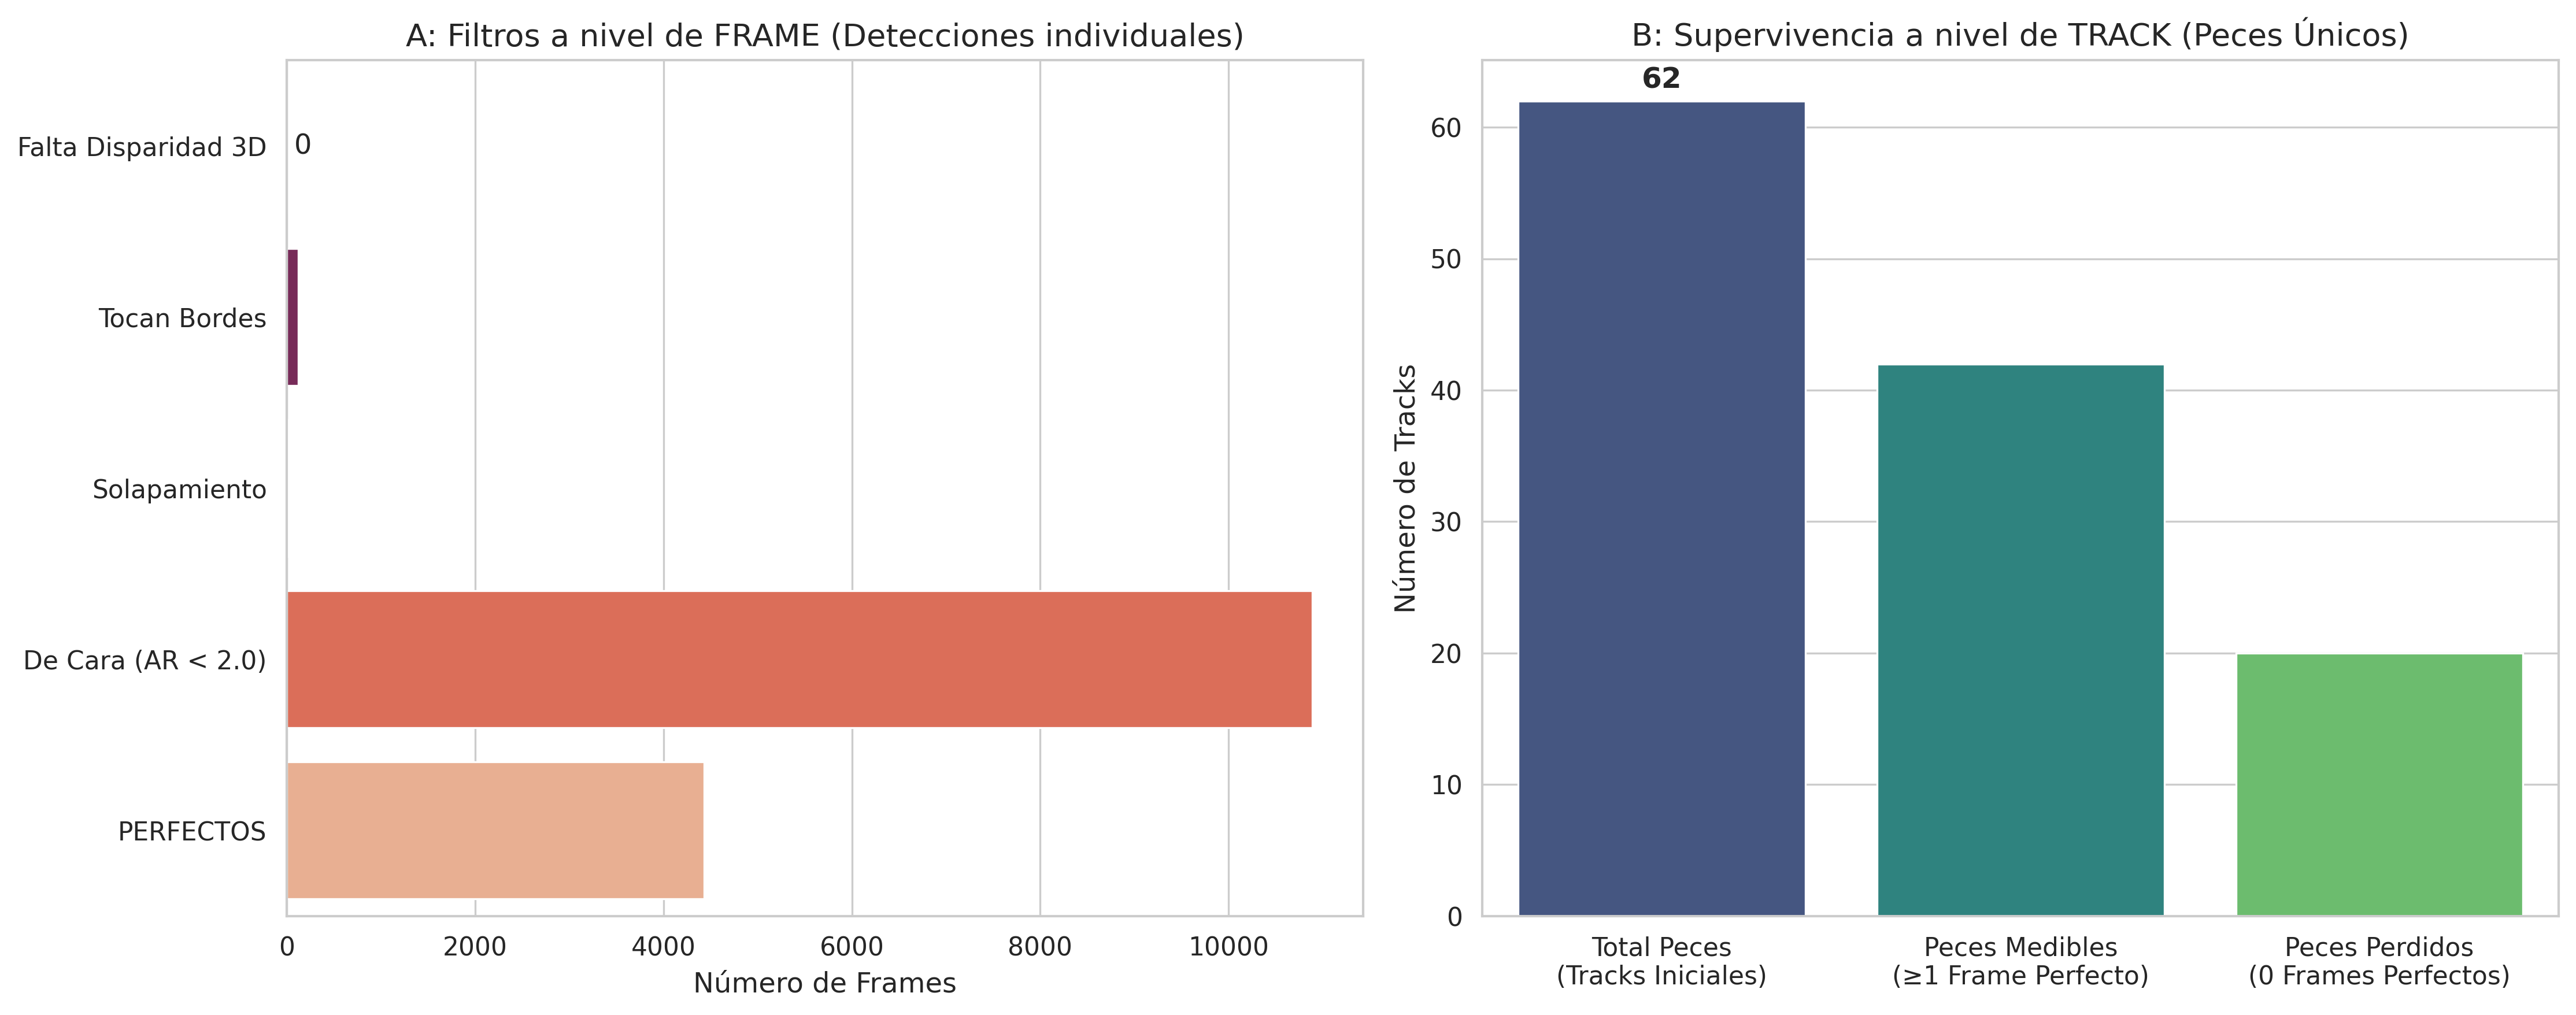

In [18]:
ASPECT_RATIO_THR = 2.0

# 1. Lógica de Frames (Tu código original)
fails_incomplete = (~df_raw['is_3D_complete']).sum()
fails_borders = df_raw['in_image_borders'].sum()
fails_overlap = df_raw['does_overlap'].sum()
fails_aspect = (df_raw['aspect_ratio'] < ASPECT_RATIO_THR).sum()

df_perfect = df_raw[
    (df_raw['is_3D_complete'] == True) &
    (df_raw['in_image_borders'] == False) &
    (df_raw['does_overlap'] == False) &
    (df_raw['aspect_ratio'] >= ASPECT_RATIO_THR) &
    (df_raw['filtered_length'] > 0)
].copy()

perfect_count = len(df_perfect)

# 2. Lógica de TRACKS (Peces reales)
# Creamos un ID único combinando carpeta y track_id
df_raw['unique_track'] = df_raw['source_folder'].astype(str) + "_" + df_raw['track_id'].astype(str)
df_perfect['unique_track'] = df_perfect['source_folder'].astype(str) + "_" + df_perfect['track_id'].astype(str)

total_tracks = df_raw['unique_track'].nunique()
surviving_tracks = df_perfect['unique_track'].nunique()
lost_tracks = total_tracks - surviving_tracks

# Porcentajes para el texto
retention_pct = (surviving_tracks / total_tracks) * 100 if total_tracks > 0 else 0
lost_pct = (lost_tracks / total_tracks) * 100 if total_tracks > 0 else 0

print(f"=== IMPACTO DEL FILTRADO EN LOS PECES (TRACKS) ===")
print(f"Total de peces detectados inicialmente: {total_tracks}")
print(f"Peces que conservan al menos 1 medida útil: {surviving_tracks} ({retention_pct:.1f}%)")
print(f"Peces perdidos por completo: {lost_tracks} ({lost_pct:.1f}%)\n")

# 3. Visualización Doble (Paper-ready)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel Izquierdo: Descarte de FRAMES ---
reasons = ['Falta Disparidad 3D', 'Tocan Bordes', 'Solapamiento', f'De Cara (AR < {ASPECT_RATIO_THR})', 'PERFECTOS']
counts = [fails_incomplete, fails_borders, fails_overlap, fails_aspect, perfect_count]

sns.barplot(x=counts, y=reasons, palette="rocket", ax=axes[0])
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].set_title("A: Filtros a nivel de FRAME (Detecciones individuales)", fontsize=13)
axes[0].set_xlabel("Número de Frames")

# --- Panel Derecho: Retención de TRACKS ---
track_labels = ['Total Peces\n(Tracks Iniciales)', 'Peces Medibles\n(≥1 Frame Perfecto)', 'Peces Perdidos\n(0 Frames Perfectos)']
track_counts = [total_tracks, surviving_tracks, lost_tracks]

sns.barplot(x=track_labels, y=track_counts, palette="viridis", ax=axes[1])
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=12, fontweight='bold')
axes[1].set_title("B: Supervivencia a nivel de TRACK (Peces Únicos)", fontsize=13)
axes[1].set_ylabel("Número de Tracks")

plt.tight_layout()
plt.show()

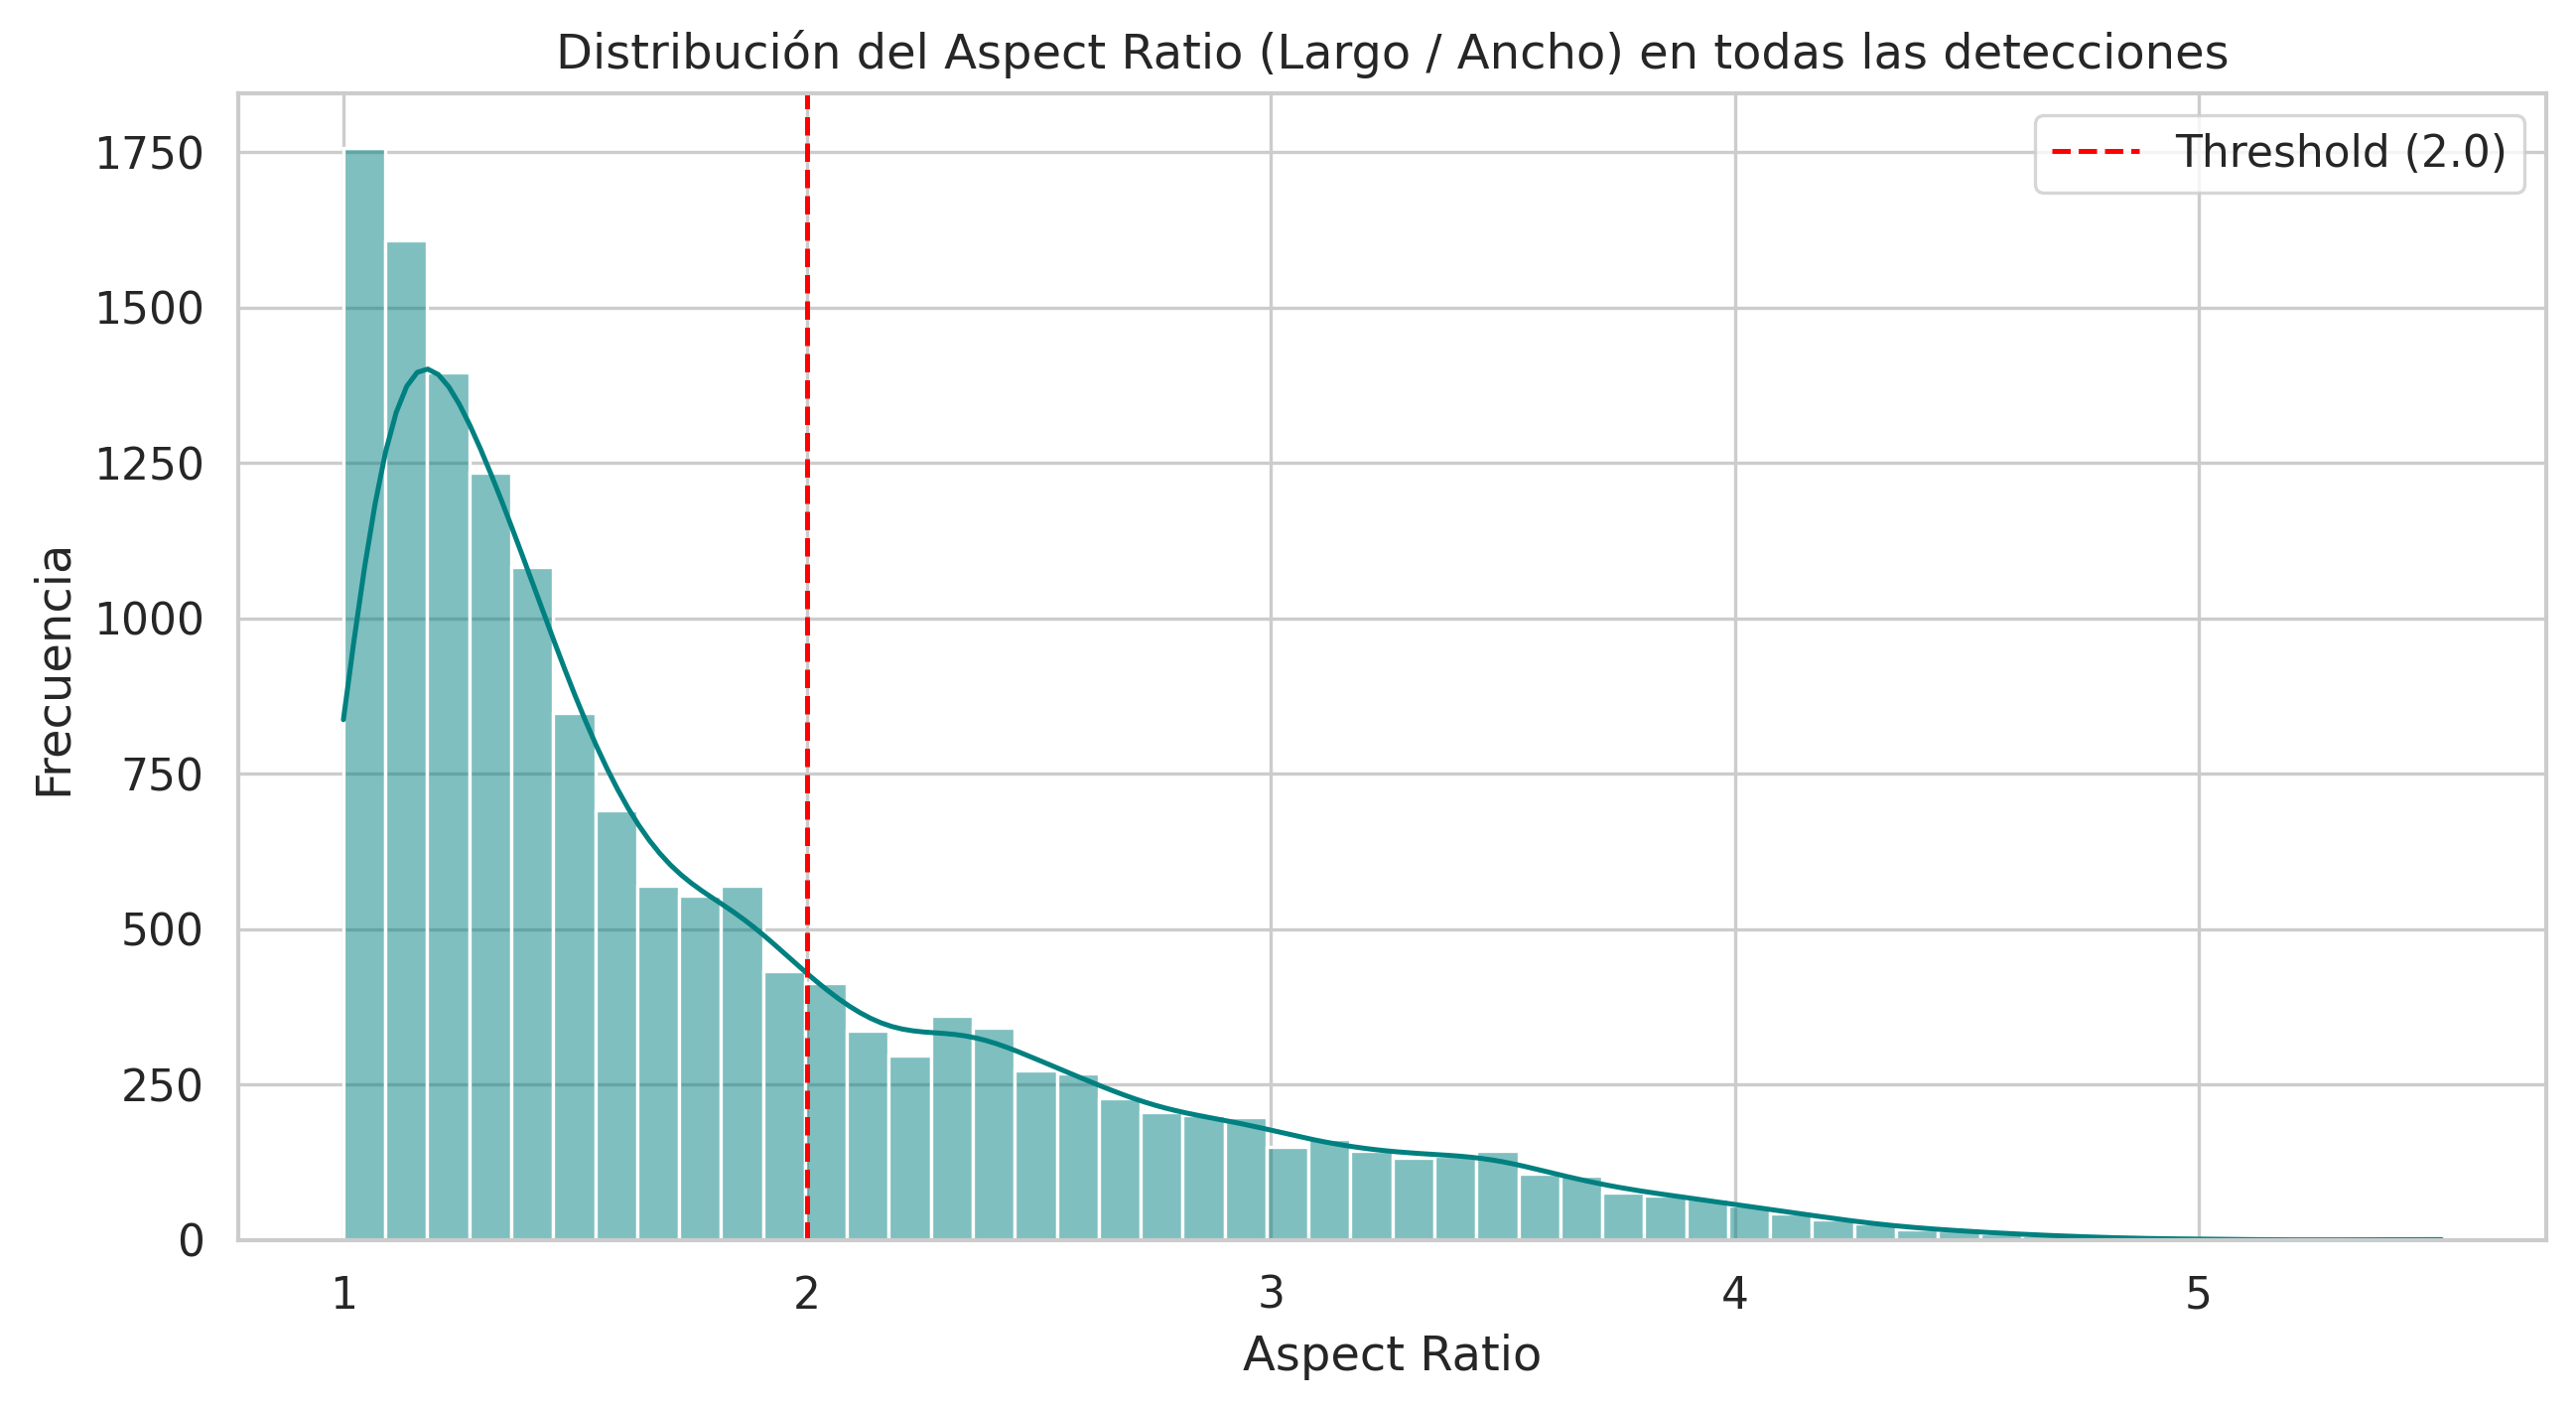

In [19]:
plt.figure(figsize=(10, 5))
# Filtramos los valores nulos o 0 para que no estropeen la gráfica
ar_data = df_raw[df_raw['aspect_ratio'] > 0]['aspect_ratio']

sns.histplot(ar_data, bins=50, kde=True, color="teal")
plt.axvline(x=ASPECT_RATIO_THR, color='red', linestyle='--', label=f'Threshold ({ASPECT_RATIO_THR})')

plt.title("Distribución del Aspect Ratio (Largo / Ancho) en todas las detecciones")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

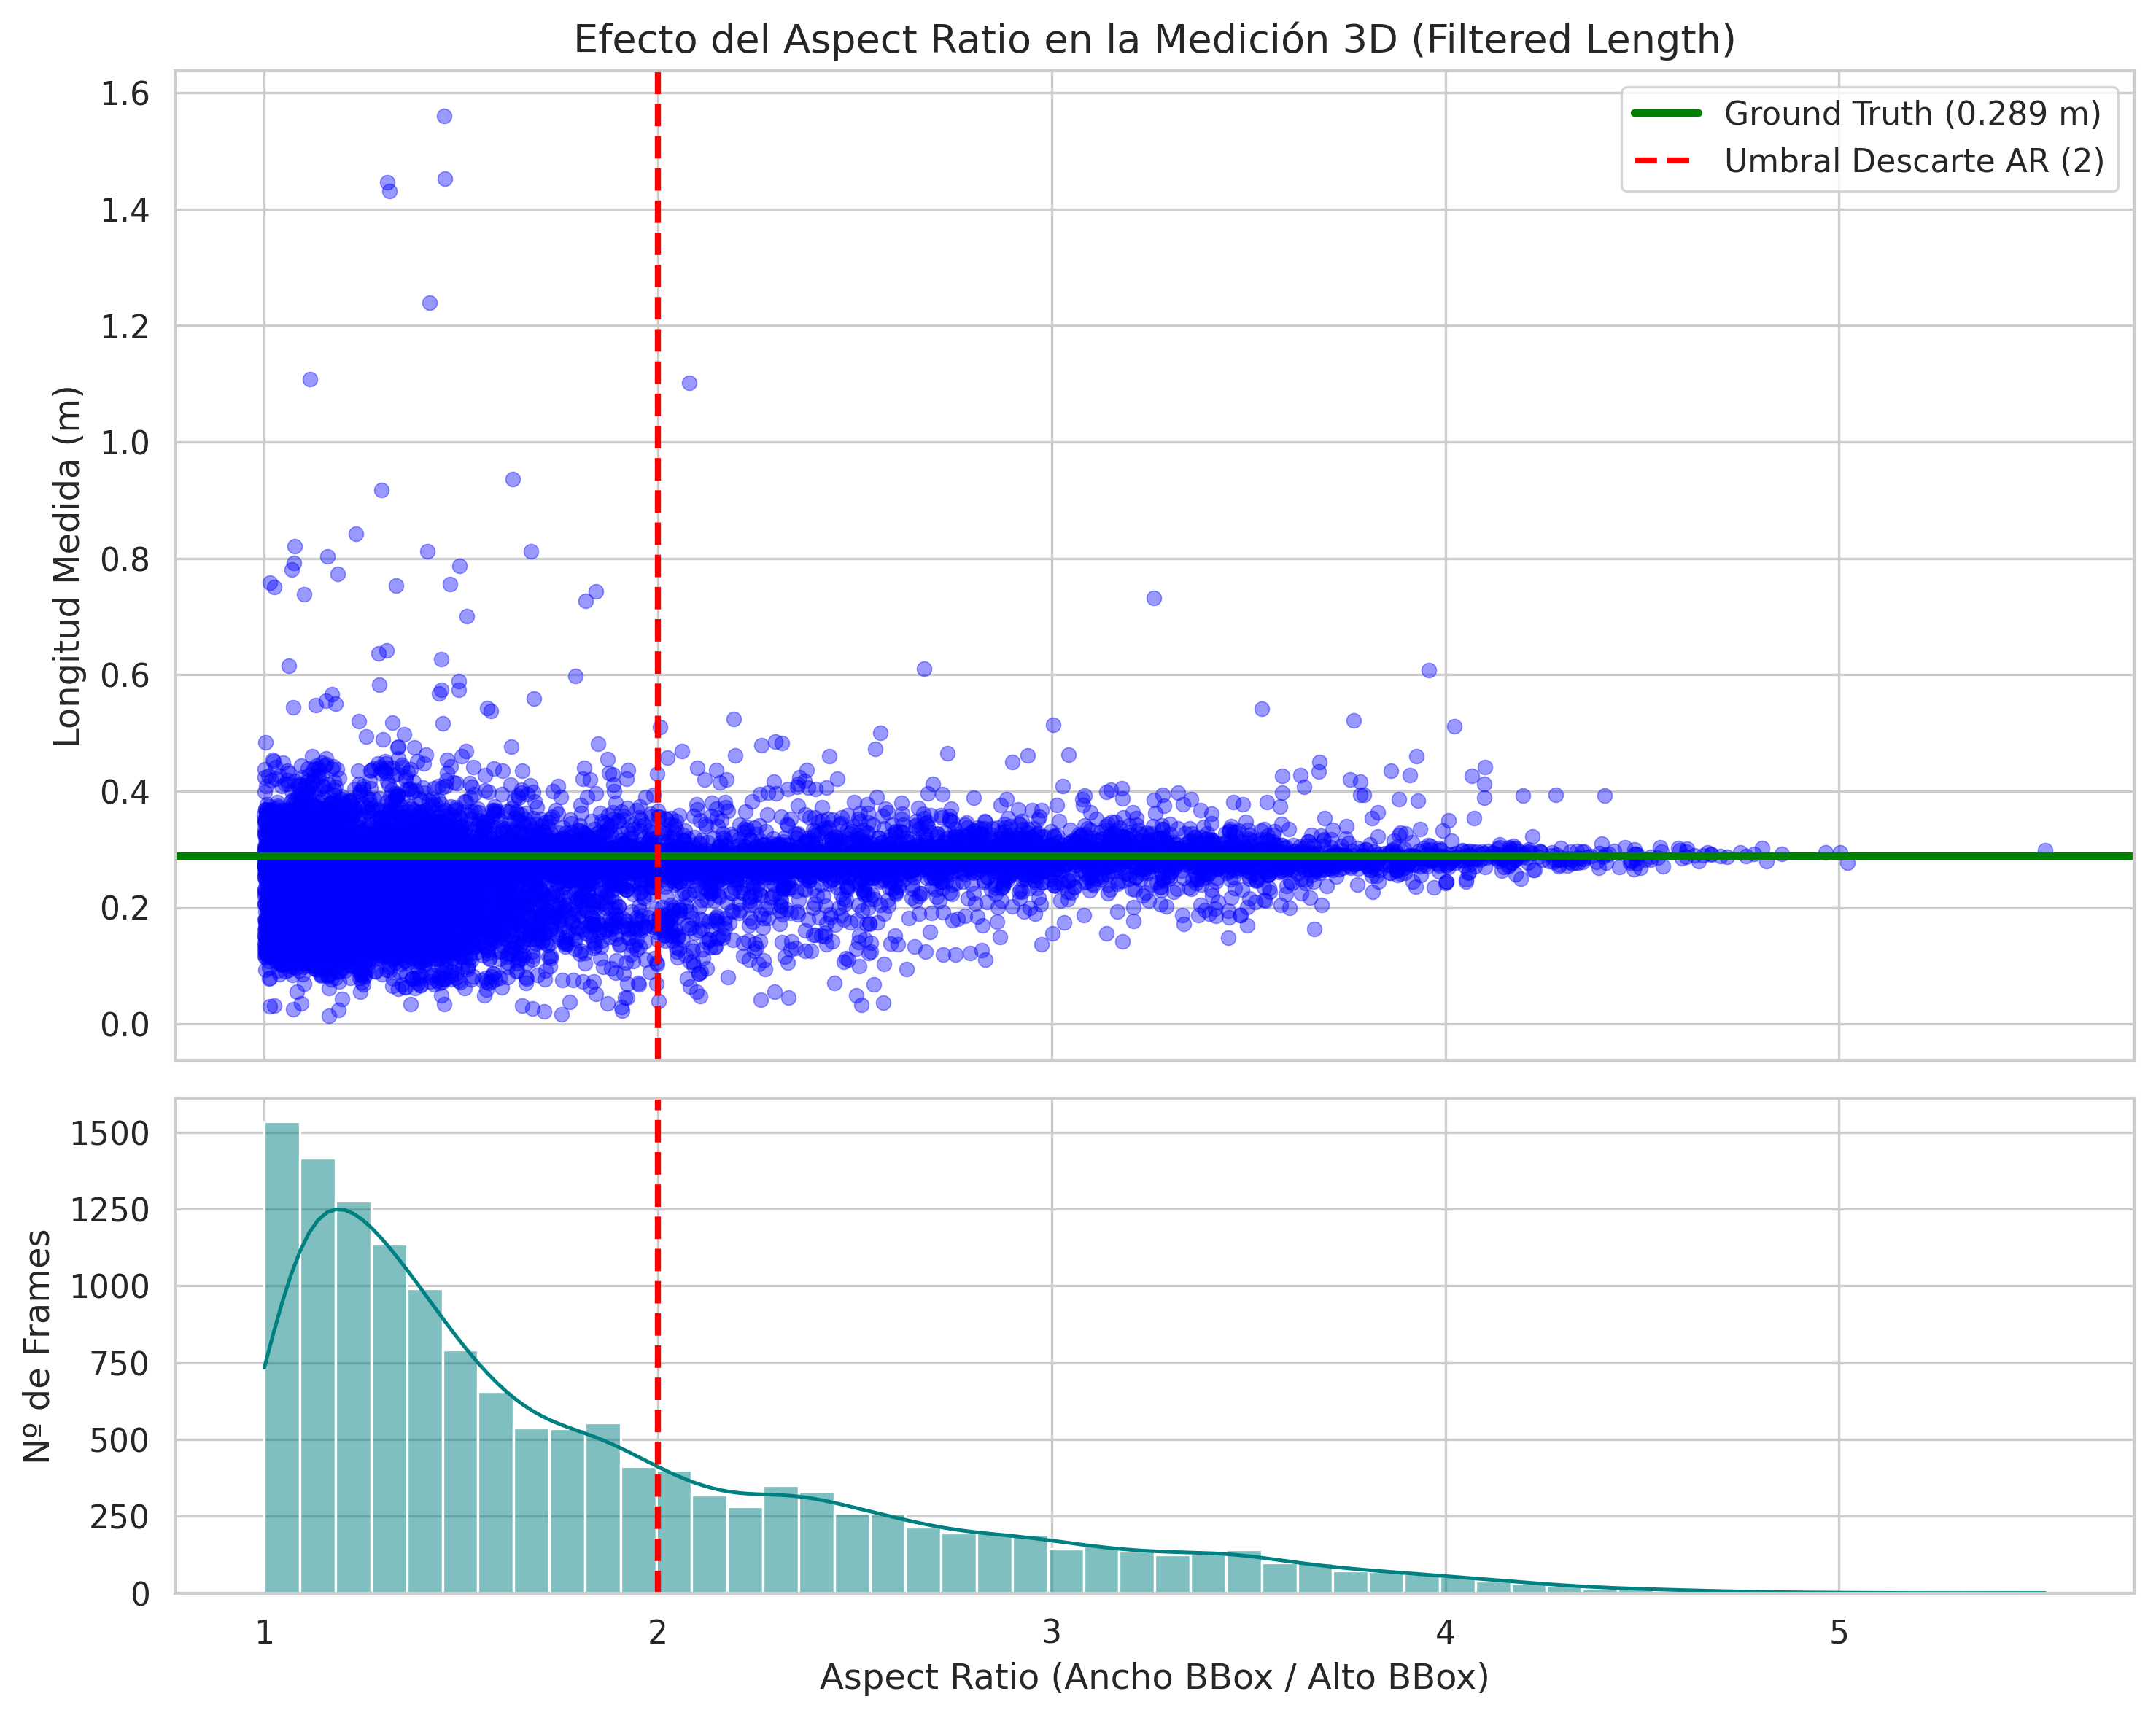

In [17]:
# Filtramos los valores válidos para evitar ceros o nulos
df_valid = df_raw[(df_raw['aspect_ratio'] > 0) & (df_raw['filtered_length'] > 0)].copy()

# Creamos la figura con 2 subplots (arriba el scatter, abajo el histograma)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# ==========================================
# PANEL SUPERIOR: Medida vs Aspect Ratio
# ==========================================
sns.scatterplot(data=df_valid, x='aspect_ratio', y='filtered_length', 
                alpha=0.4, color='blue', edgecolor=None, ax=axes[0])

# Dibujar la línea del Ground Truth (GT)
# Asumimos que la columna 'gt' está en cm y las medidas en metros.
# Si tienes varios GTs diferentes en tu dataset, esto calculará la media.
gt_medio_m = df_valid['gt'].mean() / 100.0
axes[0].axhline(y=gt_medio_m, color='green', linestyle='-', linewidth=2.5, 
                label=f'Ground Truth ({gt_medio_m:.3f} m)')

# Línea del umbral de Aspect Ratio
axes[0].axvline(x=ASPECT_RATIO_THR, color='red', linestyle='--', linewidth=2,
                label=f'Umbral Descarte AR ({ASPECT_RATIO_THR})')

axes[0].set_title("Efecto del Aspect Ratio en la Medición 3D (Filtered Length)", fontsize=13)
axes[0].set_ylabel("Longitud Medida (m)")
axes[0].legend(loc='upper right')

# ==========================================
# PANEL INFERIOR: Histograma de Frecuencia
# ==========================================
sns.histplot(data=df_valid, x='aspect_ratio', bins=50, kde=True, color="teal", ax=axes[1])
axes[1].axvline(x=ASPECT_RATIO_THR, color='red', linestyle='--', linewidth=2)

axes[1].set_ylabel("Nº de Frames")
axes[1].set_xlabel("Aspect Ratio (Ancho BBox / Alto BBox)")

plt.tight_layout()
plt.show()

In [32]:
def smart_aggregator(track_df):
    """Aplica tu lógica Smart a un único pez (track)"""
    num_frames = len(track_df)
    if num_frames < 3: return None
    
    sorted_lengths = track_df['filtered_length'].dropna().sort_values(ascending=False).tolist()
    if not sorted_lengths: return None
    
    valid_max = sorted_lengths[0]
    if len(sorted_lengths) >= 5:
        while len(sorted_lengths) > 2:
            c_max, n_max = sorted_lengths[0], sorted_lengths[1]
            c_med = np.median(sorted_lengths)
            if c_max > c_med * 2.0:
                sorted_lengths.pop(0); continue
            if (c_max - n_max) / n_max < 0.05:
                valid_max = c_max; break
            else:
                sorted_lengths.pop(0)
        if len(sorted_lengths) <= 2: valid_max = sorted_lengths[0]
            
    if num_frames < 20: 
        rep_len = valid_max
    else:
        n_top = max(1, int(len(sorted_lengths) * 0.2))
        rep_len = sum(sorted_lengths[:n_top]) / n_top
        
    gt_val = track_df['gt'].iloc[0]
    rel_err = abs((rep_len - (gt_val/100.0)) * 100) / gt_val * 100 if gt_val > 0 else None
    
    return pd.Series({
        'n_frames_validos': num_frames,
        'length_used_for_error': rep_len,
        'mean_elevation_deg': track_df['elevation_deg'].mean(),
        'mean_aspect_ratio': track_df['aspect_ratio'].mean(),
        'gt': gt_val,
        'rel_error_%': rel_err
    })


# 1. PASO 1: "all_complete_ok_fish.csv"
# (Aseguramos que solo entran las detecciones impecables)
df_all_complete_ok = df_raw[
    (df_raw['is_3D_complete'] == True) &
    (df_raw['in_image_borders'] == False) &
    (df_raw['does_overlap'] == False) &
    (df_raw['aspect_ratio'] >= ASPECT_RATIO_THR) &
    (df_raw['filtered_length'] > 0)
].copy()

# 2. PASO 2: "resume_filtered_smart.csv"
# (Agrupamos los frames buenos por cada Track ID)
df_resume_smart = df_all_complete_ok.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# 3. PASO 3: "resume_filtered_smart_angle_ok.csv"
# (Aplicamos el filtro final de Ángulo Z <= 20º a los peces ya agrupados)
df_resume_smart_angle_ok = df_resume_smart[df_resume_smart['mean_elevation_deg'].abs() <= ANGLE_THR].copy()

# --- RESUMEN DE LA CASCADA ---
print("=== CASCADA DE PROCESAMIENTO ===")
print(f"1. Detecciones individuales RAW: {len(df_raw)}")
print(f"2. Detecciones individuales OK (all_complete_ok_fish): {len(df_all_complete_ok)}")
print(f"3. Peces únicos medidos tras Agrupación Smart (resume_filtered_smart): {len(df_resume_smart)}")
print(f"4. Peces finales tras filtro Ángulo <= {ANGLE_THR}º (resume_smart_angle_ok): {len(df_resume_smart_angle_ok)}")

=== CASCADA DE PROCESAMIENTO ===
1. Detecciones individuales RAW: 15503
2. Detecciones individuales OK (all_complete_ok_fish): 4431
3. Peces únicos medidos tras Agrupación Smart (resume_filtered_smart): 36
4. Peces finales tras filtro Ángulo <= 20.0º (resume_smart_angle_ok): 15


/tmp/ipykernel_98692/2144168207.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_resume_smart = df_all_complete_ok.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()


In [41]:
df_res_5_angle

,source_folder,track_id,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg
4,12_07_31_1,8,38.0,29.479814,28.9,0.579814,18.009655
8,12_10_35_compressed,1,132.0,30.385353,28.9,1.485353,-10.255694
10,12_12_06_compressed,1,102.0,37.142037,28.9,8.242037,9.353066
12,12_13_38_compressed,1,101.0,35.554195,28.9,6.654195,7.203475
15,13_33_03_0,3,186.0,29.857073,28.9,0.957073,13.914916
16,13_33_03_1,1,206.0,29.529116,28.9,0.629116,8.982896
18,13_35_56_compressed,1,115.0,29.802913,28.9,0.902913,14.176252
19,13_37_28_compressed,1,232.0,29.975027,28.9,1.075027,1.300032
20,13_37_28_compressed,3,182.0,35.291458,28.9,6.391458,10.587978
21,13_38_54_compressed,1,218.0,31.643260,28.9,2.743260,9.167061


Calculando el impacto de cada filtro... (esto puede tardar unos segundos)

ETAPA DEL PIPELINE (CASCADA)             | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
-----------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)            |  4.67 ± 3.83 cm |   14295 frames |    52 tracks
1. + Filtro: is_3D_complete              |  4.67 ± 3.83 cm |   14295 frames |    52 tracks
2. + Filtro: Sin Bordes                  |  4.67 ± 3.83 cm |   14295 frames |    52 tracks
3. + Filtro: Sin Solapamiento            |  4.67 ± 3.84 cm |   14278 frames |    52 tracks
4. + Filtro: Aspect Ratio >= 2.0         |  4.17 ± 3.58 cm |    4431 frames |    36 tracks
5. + Filtro: Ángulo Z <= 20.0º           |  3.22 ± 2.88 cm |    1047 frames |    15 tracks


/tmp/ipykernel_98692/3983074877.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_res_0_base = df_base.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()
/tmp/ipykernel_98692/3983074877.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_res_1_3D = df_base[mask_1].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()
/tmp/ipykernel_98692/398

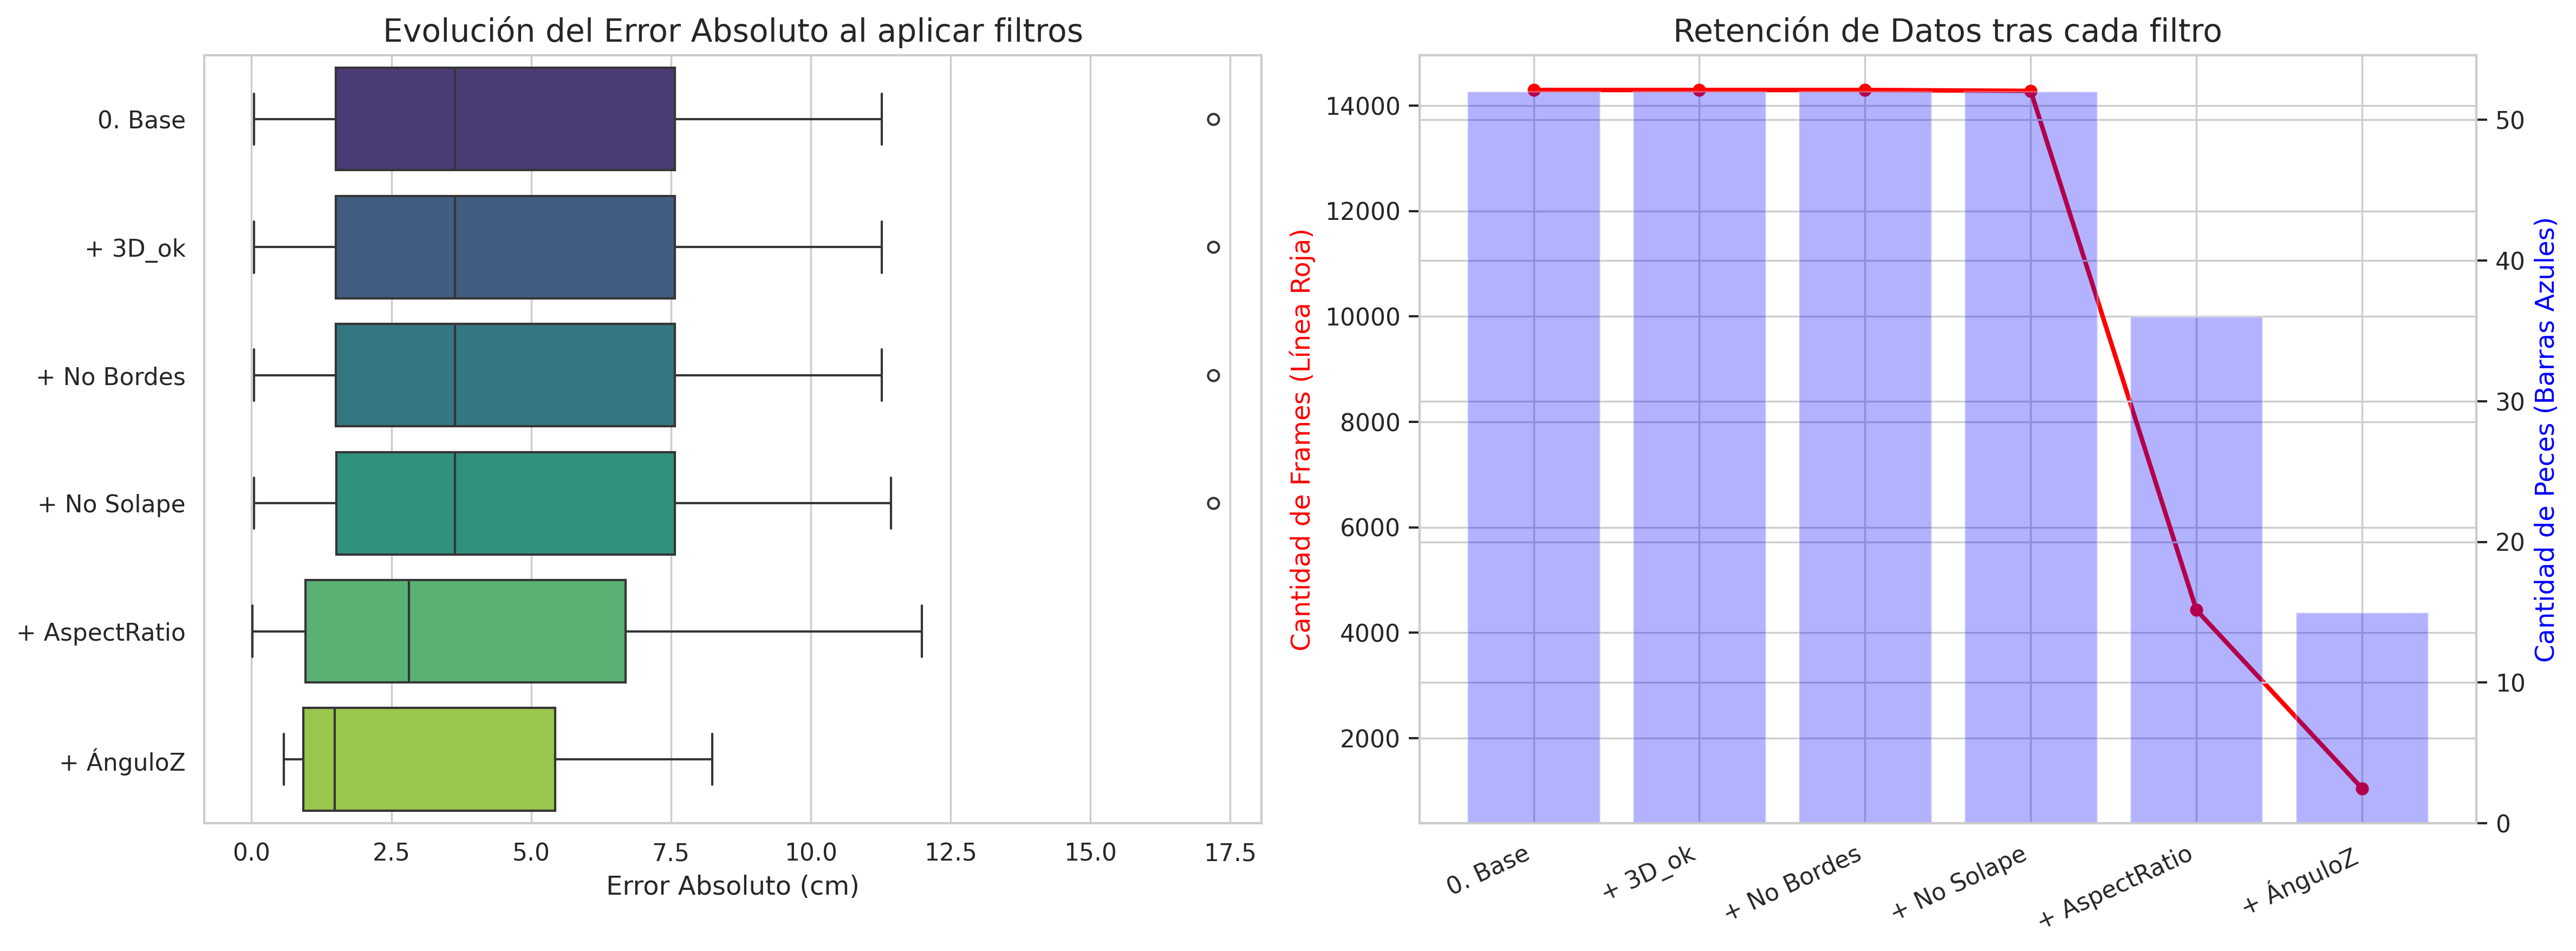

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. FUNCIÓN DE AGRUPACIÓN (Ahora expone las medidas reales y el GT)
# =====================================================================

def smart_aggregator(track_df, length_col='filtered_length'):
    """Agrupación inteligente (Top 20% + Filtro de saltos) devolviendo datos completos"""
    num_frames = len(track_df)
    if num_frames < 3: return None
    
    sorted_lengths = track_df[length_col].dropna().sort_values(ascending=False).tolist()
    if not sorted_lengths: return None
    
    valid_max = sorted_lengths[0]
    if len(sorted_lengths) >= 5:
        while len(sorted_lengths) > 2:
            c_max, n_max = sorted_lengths[0], sorted_lengths[1]
            c_med = np.median(sorted_lengths)
            if c_max > c_med * 2.0:
                sorted_lengths.pop(0); continue
            if (c_max - n_max) / n_max < 0.05:
                valid_max = c_max; break
            else:
                sorted_lengths.pop(0)
        if len(sorted_lengths) <= 2: valid_max = sorted_lengths[0]
            
    if num_frames < 20: 
        rep_len_m = valid_max
    else:
        n_top = max(1, int(len(sorted_lengths) * 0.2))
        rep_len_m = sum(sorted_lengths[:n_top]) / n_top
        
    # Calcular variables en Centímetros
    gt_cm = track_df['gt'].iloc[0]
    calculated_length_cm = rep_len_m * 100.0
    abs_err_cm = abs(calculated_length_cm - gt_cm) if gt_cm > 0 else None
    
    # Añadimos las nuevas columnas al output
    return pd.Series({
        'n_frames_validos': num_frames,
        'calculated_length_cm': calculated_length_cm,
        'gt_cm': gt_cm,
        'abs_error_cm': abs_err_cm,
        'mean_elevation_deg': track_df['elevation_deg'].mean()
    })

# =====================================================================
# 2. ESTUDIO DE ABLACIÓN (Añadiendo filtros uno a uno en cascada)
# =====================================================================
print("Calculando el impacto de cada filtro... (esto puede tardar unos segundos)\n")

# Aseguramos que al menos haya una medida 3D para poder comparar (Línea base)
df_base = df_raw[df_raw['filtered_length'] > 0].copy()

# PASO 0: Línea Base
df_res_0_base = df_base.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 1: Exigir que el pez esté completo en 3D
mask_1 = (df_base['is_3D_complete'] == True)
df_res_1_3D = df_base[mask_1].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 2: Pez Completo + NO tocar bordes
mask_2 = mask_1 & (df_base['in_image_borders'] == False)
df_res_2_borders = df_base[mask_2].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 3: Completo + Sin bordes + SIN solapamiento
mask_3 = mask_2 & (df_base['does_overlap'] == False)
df_res_3_overlap = df_base[mask_3].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 4: Completo + Sin bordes + Sin solape + ASPECT RATIO
mask_4 = mask_3 & (df_base['aspect_ratio'] >= ASPECT_RATIO_THR)
df_res_4_aspect = df_base[mask_4].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 5: Todo lo anterior + ÁNGULO Z <= 20º
df_res_5_angle = df_res_4_aspect[df_res_4_aspect['mean_elevation_deg'].abs() <= ANGLE_THR].copy()

frames_count = [len(df_base), mask_1.sum(), mask_2.sum(), mask_3.sum(), mask_4.sum(), len(df_base[mask_4 & (df_base['elevation_deg'].abs() <= ANGLE_THR)])]

# =====================================================================
# 3. IMPRIMIR TABLA RESUMEN PARA EL PAPER
# =====================================================================
stages_dict = {
    "0. Base (HDBSCAN sin filtros)": df_res_0_base,
    "1. + Filtro: is_3D_complete": df_res_1_3D,
    "2. + Filtro: Sin Bordes": df_res_2_borders,
    "3. + Filtro: Sin Solapamiento": df_res_3_overlap,
    f"4. + Filtro: Aspect Ratio >= {ASPECT_RATIO_THR}": df_res_4_aspect,
    f"5. + Filtro: Ángulo Z <= {ANGLE_THR}º": df_res_5_angle
}

print(f"{'ETAPA DEL PIPELINE (CASCADA)':<40} | {'ERROR MEDIO':<15} | {'FRAMES VIVOS':<15} | {'PECES (TRACKS)'}")
print("-" * 95)

for (name, df_stage), f_count in zip(stages_dict.items(), frames_count):
    if df_stage.empty:
        print(f"{name:<40} | --- VACÍO ---")
        continue
        
    mean_err = df_stage['abs_error_cm'].mean()
    std_err = df_stage['abs_error_cm'].std()
    total_tracks = len(df_stage)
    
    print(f"{name:<40} | {mean_err:>5.2f} ± {std_err:>4.2f} cm | {f_count:>7} frames | {total_tracks:>5} tracks")

# =====================================================================
# 4. GRÁFICOS DE IMPACTO
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
stage_names = ["0. Base", "+ 3D_ok", "+ No Bordes", "+ No Solape", "+ AspectRatio", "+ ÁnguloZ"]

# --- PANEL IZQUIERDO: Evolución del Error Absoluto (Boxplot) ---
plot_data = []
for name, short_name in zip(stages_dict.values(), stage_names):
    if not name.empty:
        temp_df = pd.DataFrame({'Etapa': short_name, 'Error Absoluto (cm)': name['abs_error_cm']})
        plot_data.append(temp_df)

df_plot = pd.concat(plot_data)

sns.boxplot(data=df_plot, x='Error Absoluto (cm)', y='Etapa', palette="viridis", ax=axes[0])
axes[0].set_title("Evolución del Error Absoluto al aplicar filtros", fontsize=14)
axes[0].set_xlabel("Error Absoluto (cm)")
axes[0].set_ylabel("")

# --- PANEL DERECHO: El "Costo" del filtrado (Retención de Datos) ---
tracks_count = [len(df) for df in stages_dict.values()]

ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(stage_names, frames_count, color='red', marker='o', linewidth=2, label='Frames Útiles')
ax2.bar(stage_names, tracks_count, color='blue', alpha=0.3, label='Peces Retenidos (Tracks)')

ax1.set_ylabel("Cantidad de Frames (Línea Roja)", color='red')
ax2.set_ylabel("Cantidad de Peces (Barras Azules)", color='blue')
axes[1].set_title("Retención de Datos tras cada filtro", fontsize=14)

ax1.set_xticklabels(stage_names, rotation=25, ha="right")

plt.tight_layout()
plt.show()

Calculando barrido de Aspect Ratio...



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 66.26it/s]


Calculando barrido de Ángulo de Elevación...



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 96.54it/s]


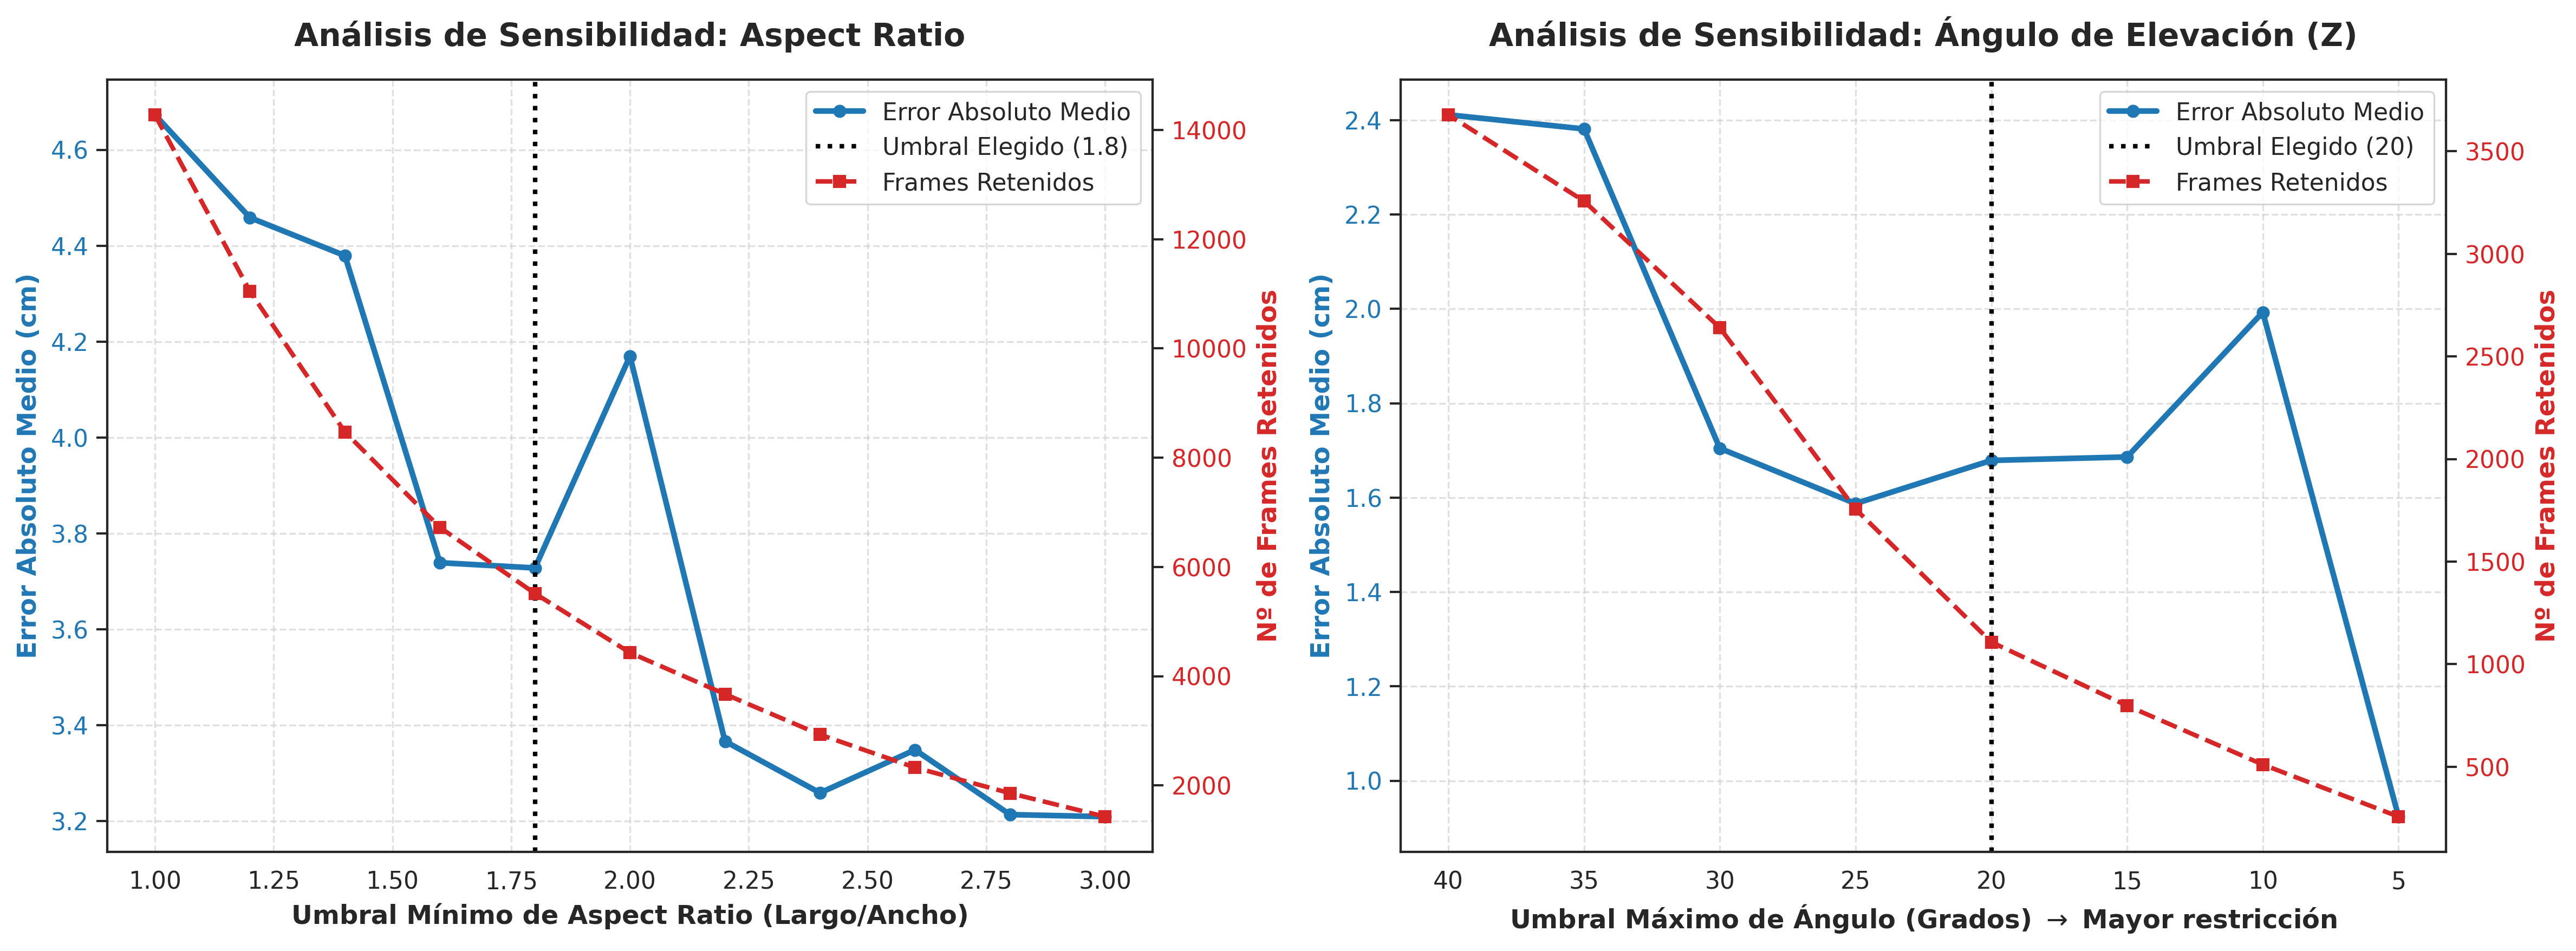

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm # Para ver la barra de progreso en Jupyter
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. PREPARAR DATOS BASE (Aplicamos filtros de calidad básicos primero)
# =====================================================================
df_base = df_raw[
    (df_raw['is_3D_complete'] == True) &
    (df_raw['in_image_borders'] == False) &
    (df_raw['does_overlap'] == False) &
    (df_raw['filtered_length'] > 0)
].copy()

# =====================================================================
# 2. FUNCIÓN DE EVALUACIÓN (Simula todo el pipeline de golpe)
# =====================================================================
def evaluate_thresholds(df, ar_thr, angle_thr):
    """Filtra por los umbrales dados y calcula el error final con el Smart Aggregator"""
    # 1. Filtrar
    df_filt = df[(df['aspect_ratio'] >= ar_thr) & (df['elevation_deg'].abs() <= angle_thr)]
    if df_filt.empty: return np.nan, 0, 0
    
    # 2. Agrupar (Llamamos a tu función smart_aggregator que ya tienes definida en la celda anterior)
    # NOTA: Asegúrate de haber ejecutado la celda donde definiste `smart_aggregator`
    df_agg = df_filt.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()
    if df_agg.empty: return np.nan, 0, 0
    
    # 3. Métricas
    mean_err = df_agg['abs_error_cm'].mean()
    retained_frames = len(df_filt)
    retained_tracks = len(df_agg)
    
    return mean_err, retained_frames, retained_tracks

# =====================================================================
# 3. BARRIDO DE PARÁMETROS (SENSITIVITY ANALYSIS)
# =====================================================================
print("Calculando barrido de Aspect Ratio...")
ar_range = np.arange(1.0, 3.2, 0.2) # De 1.0 a 3.0 saltando de 0.2 en 0.2
ar_errors, ar_frames = [], []

# Para aislar el efecto del Aspect Ratio, dejamos el ángulo libre (ej. 90º)
for ar in tqdm(ar_range):
    err, frames, _ = evaluate_thresholds(df_base, ar_thr=ar, angle_thr=90.0)
    ar_errors.append(err)
    ar_frames.append(frames)

print("Calculando barrido de Ángulo de Elevación...")
angle_range = np.arange(5, 45, 5) # De 5º a 40º saltando de 5 en 5
angle_errors, angle_frames = [], []

# Para aislar el efecto del Ángulo, fijamos un Aspect Ratio razonable (ej. 1.8)
for ang in tqdm(angle_range):
    err, frames, _ = evaluate_thresholds(df_base, ar_thr=1.8, angle_thr=ang)
    angle_errors.append(err)
    angle_frames.append(frames)

# =====================================================================
# 4. PLOTEAR: GRÁFICO DE DOBLE EJE PARA EL PAPER
# =====================================================================
sns.set_theme(style="white", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Función auxiliar para plotear con doble eje
def plot_dual_axis(ax, x_data, y_error, y_frames, title, xlabel, optimal_x):
    # Eje Izquierdo: Error (Azul)
    color_err = '#1f77b4' # Azul matplotlib
    ax.plot(x_data, y_error, marker='o', color=color_err, linewidth=2.5, label='Error Absoluto Medio')
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel('Error Absoluto Medio (cm)', color=color_err, fontweight='bold')
    ax.tick_params(axis='y', labelcolor=color_err)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Eje Derecho: Frames Retenidos (Rojo)
    ax2 = ax.twinx()
    color_frames = '#d62728' # Rojo matplotlib
    ax2.plot(x_data, y_frames, marker='s', color=color_frames, linestyle='--', linewidth=2, label='Frames Retenidos')
    ax2.set_ylabel('Nº de Frames Retenidos', color=color_frames, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_frames)
    
    # Marcar el punto óptimo elegido (El "Codo")
    ax.axvline(x=optimal_x, color='black', linestyle=':', linewidth=2, label=f'Umbral Elegido ({optimal_x})')
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    # Juntar leyendas de ambos ejes
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

# Panel Izquierdo: Aspect Ratio
plot_dual_axis(axes[0], ar_range, ar_errors, ar_frames, 
               title="Análisis de Sensibilidad: Aspect Ratio", 
               xlabel="Umbral Mínimo de Aspect Ratio (Largo/Ancho)", 
               optimal_x=1.8) # Cambia 1.8 por tu umbral real si es otro

# Panel Derecho: Ángulo de Elevación
# Invertimos el eje X del ángulo (o lo leemos de derecha a izquierda) porque un umbral MENOR es más estricto
plot_dual_axis(axes[1], angle_range, angle_errors, angle_frames, 
               title="Análisis de Sensibilidad: Ángulo de Elevación (Z)", 
               xlabel="Umbral Máximo de Ángulo (Grados)", 
               optimal_x=20) # Cambia 20 por tu umbral real

# Para el ángulo, como es "menor que", al subir el umbral retienes más frames pero sube el error. 
# Para que se lea igual que el otro (filtro más estricto a la derecha), invertimos el eje X:
axes[1].invert_xaxis()
axes[1].set_xlabel("Umbral Máximo de Ángulo (Grados) $\\rightarrow$ Mayor restricción")

plt.tight_layout()
plt.show()

Calculando interacción entre Aspect Ratio y Ángulo...



Evaluando Ángulos: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00,  6.50it/s]


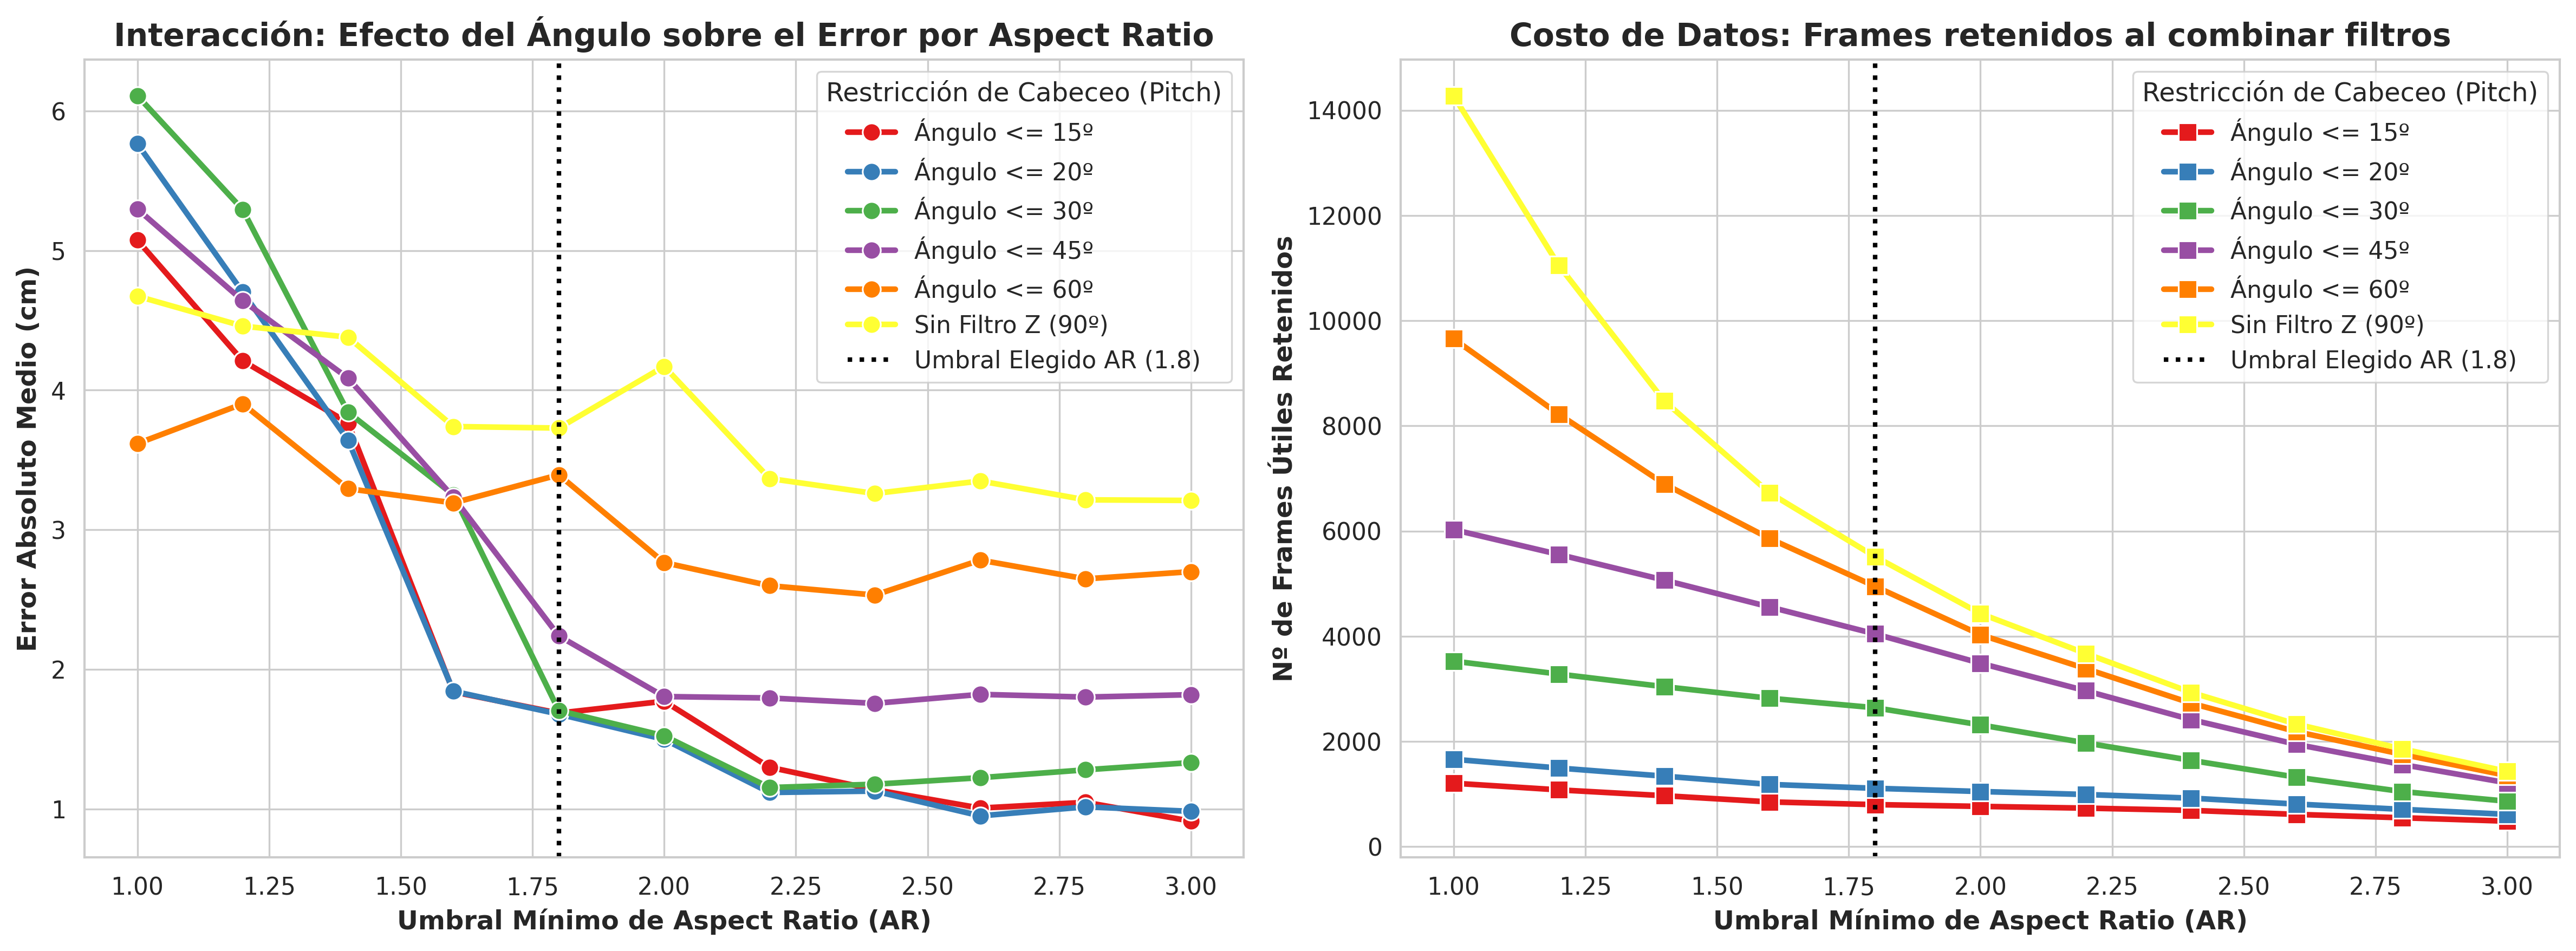

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# =====================================================================
# 1. RECOPILAR DATOS COMBINADOS
# =====================================================================
print("Calculando interacción entre Aspect Ratio y Ángulo...")

ar_range = np.arange(1.0, 3.2, 0.2)
# Probamos tu ángulo óptimo (20), uno más estricto (15), uno más relajado (30) y sin filtro (90)
angles_to_test = [15, 20, 30, 45, 60, 90] 

results = []

for ang in tqdm(angles_to_test, desc="Evaluando Ángulos"):
    for ar in ar_range:
        err, frames, tracks = evaluate_thresholds(df_base, ar_thr=ar, angle_thr=ang)
        
        # Etiqueta para la leyenda
        if ang == 90:
            ang_label = "Sin Filtro Z (90º)"
        else:
            ang_label = f"Ángulo <= {ang}º"
            
        results.append({
            'Angle_Thr': ang_label,
            'AR_Thr': ar,
            'Error_cm': err,
            'Frames': frames,
            'Tracks': tracks
        })

df_interaction = pd.DataFrame(results)

# =====================================================================
# 2. PLOTEAR INTERACCIÓN (PAPER-READY)
# =====================================================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Paleta de colores: que resalte bien la diferencia entre líneas
palette = sns.color_palette("Set1", n_colors=len(angles_to_test))

# --- PANEL IZQUIERDO: ERROR ABSOLUTO ---
sns.lineplot(data=df_interaction, x='AR_Thr', y='Error_cm', hue='Angle_Thr', 
             marker='o', markersize=8, linewidth=2.5, palette=palette, ax=axes[0])

axes[0].axvline(x=1.8, color='black', linestyle=':', linewidth=2, label='Umbral Elegido AR (1.8)')
axes[0].set_title("Interacción: Efecto del Ángulo sobre el Error por Aspect Ratio", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Umbral Mínimo de Aspect Ratio (AR)", fontweight='bold')
axes[0].set_ylabel("Error Absoluto Medio (cm)", fontweight='bold')
axes[0].legend(title="Restricción de Cabeceo (Pitch)")

# --- PANEL DERECHO: FRAMES RETENIDOS ---
sns.lineplot(data=df_interaction, x='AR_Thr', y='Frames', hue='Angle_Thr', 
             marker='s', markersize=8, linewidth=2.5, palette=palette, ax=axes[1])

axes[1].axvline(x=1.8, color='black', linestyle=':', linewidth=2, label='Umbral Elegido AR (1.8)')
axes[1].set_title("Costo de Datos: Frames retenidos al combinar filtros", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Umbral Mínimo de Aspect Ratio (AR)", fontweight='bold')
axes[1].set_ylabel("Nº de Frames Útiles Retenidos", fontweight='bold')
axes[1].legend(title="Restricción de Cabeceo (Pitch)")

plt.tight_layout()
plt.show()

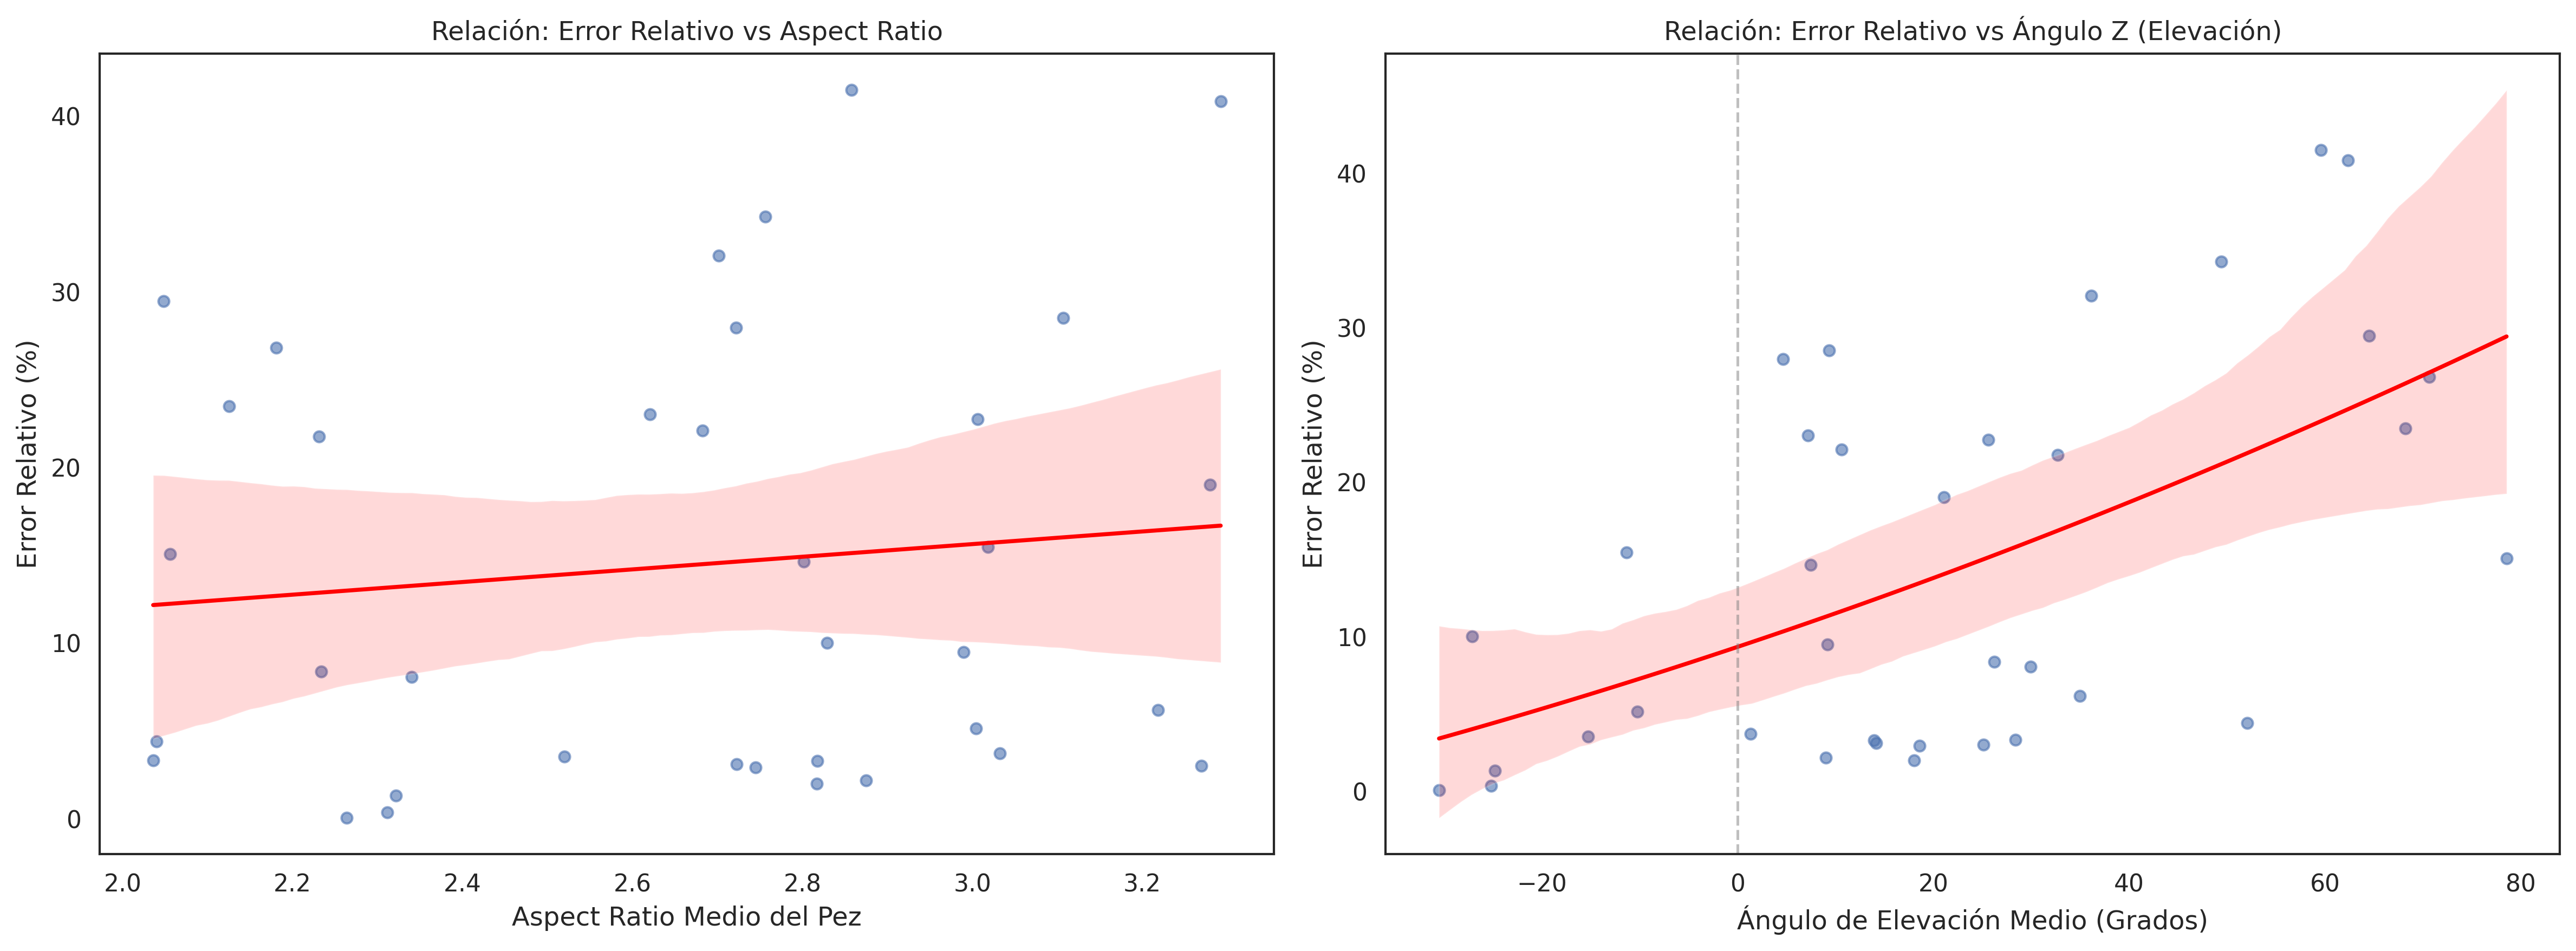

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error vs Aspect Ratio
sns.regplot(data=df_smart_all, x='mean_aspect_ratio', y='rel_error_%', ax=axes[0], 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title("Relación: Error Relativo vs Aspect Ratio")
axes[0].set_xlabel("Aspect Ratio Medio del Pez")
axes[0].set_ylabel("Error Relativo (%)")

# Error vs Elevación Z
sns.regplot(data=df_smart_all, x='mean_elevation_deg', y='rel_error_%', ax=axes[1], 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'}, order=2) # Order 2 busca curvas (parábolas)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title("Relación: Error Relativo vs Ángulo Z (Elevación)")
axes[1].set_xlabel("Ángulo de Elevación Medio (Grados)")
axes[1].set_ylabel("Error Relativo (%)")

plt.tight_layout()
plt.show()

In [24]:
def plot_track_evolution(df, folder_code, track_id):
    """
    Plotea la evolución temporal de las medidas RAW vs FILTRADAS de un pez específico.
    df: Tu macro-dataframe raw (df_raw)
    """
    # Aislar el pez
    fish_data = df[(df['source_folder'] == folder_code) & (df['track_id'] == track_id)].copy()
    
    if fish_data.empty:
        print(f"No se encontraron datos para la carpeta '{folder_code}' y track '{track_id}'")
        return
    
    # Ordenar por frame
    fish_data = fish_data.sort_values(by='frame_id')
    gt_cm = fish_data['gt'].iloc[0]
    gt_m = gt_cm / 100.0 if gt_cm > 0 else None
    
    plt.figure(figsize=(12, 6))
    
    # Ploteamos Raw Length
    plt.plot(fish_data['frame_id'], fish_data['raw_length'], 
             marker='o', linestyle='-', color='orange', alpha=0.6, label='Raw Length 3D')
    
    # Ploteamos Filtered Length (PC Limpio)
    plt.plot(fish_data['frame_id'], fish_data['filtered_length'], 
             marker='s', linestyle='-', color='blue', alpha=0.8, label='Filtered Length (HDBSCAN)')
    
    # Ploteamos el Ground Truth como línea base
    if gt_m is not None:
        plt.axhline(y=gt_m, color='green', linestyle='--', linewidth=2.5, 
                    label=f'Ground Truth ({gt_m:.3f} m)')
        
    # Sombreamos las zonas donde el pez no era "perfecto" (ej. se giró mucho o tocó borde)
    perfect_mask = (fish_data['is_3D_complete'] == True) & (fish_data['aspect_ratio'] >= ASPECT_RATIO_THR)
    bad_frames = fish_data[~perfect_mask]['frame_id']
    for bf in bad_frames:
        plt.axvspan(bf-0.5, bf+0.5, color='red', alpha=0.1)
        
    # Parche invisible para la leyenda de frames malos
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color='red', alpha=0.1, label='Frame NO Perfecto (Descartado)')

    handles, labels = plt.gca().get_legend_handles_labels()
    handles.append(red_patch)

    plt.title(f"Evolución Temporal de las Medidas - [Carpeta: {folder_code} | Track ID: {track_id}]", fontsize=14)
    plt.xlabel("ID del Frame", fontsize=12)
    plt.ylabel("Longitud Medida (Metros)", fontsize=12)
    plt.legend(handles=handles, loc='best')
    plt.show()

# EJEMPLO DE USO (Cambia el nombre de la carpeta y el ID del pez por uno que sepas que mola)
plot_track_evolution(df_raw, "13_44_55", 1)

No se encontraron datos para la carpeta '13_44_55' y track '1'


In [29]:
df_raw

,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,...,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,unique_track
0,12_09_03_compressed,frame_0,0,255,1,True,False,False,True,2.230392,...,67.619721,37.106544,-1.0,0.322840,0.316668,28.9,3.384030,11.709446,1.663082,12_09_03_compressed_1
1,12_09_03_compressed,frame_1,0,255,1,True,False,False,True,2.327831,...,66.080659,37.133779,-1.0,0.308119,0.328139,28.9,1.911855,6.615414,1.659265,12_09_03_compressed_1
2,12_09_03_compressed,frame_2,0,255,1,True,False,False,True,2.515516,...,50.109826,25.106295,-1.0,0.249701,0.228324,28.9,3.929863,13.598142,1.693085,12_09_03_compressed_1
3,12_09_03_compressed,frame_3,0,255,1,True,False,False,True,3.011830,...,58.247246,14.057908,-1.0,0.300613,0.282332,28.9,1.161328,4.018435,1.678158,12_09_03_compressed_1
4,12_09_03_compressed,frame_4,0,255,1,True,False,False,True,3.396303,...,44.696387,13.541004,-1.0,0.257552,0.244369,28.9,3.144761,10.881526,1.710066,12_09_03_compressed_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15498,12_07_31_0,frame_662,0,255,1,True,False,False,True,1.393487,...,79.294583,-50.546886,-1.0,0.340876,0.338881,28.9,5.187628,17.950270,1.795066,12_07_31_0_1
15499,12_07_31_0,frame_663,0,255,1,True,False,False,True,1.434131,...,76.837679,-46.298834,-1.0,0.350149,0.356385,28.9,6.114872,21.158726,1.786328,12_07_31_0_1
15500,12_07_31_0,frame_664,0,255,1,True,False,False,True,1.456936,...,77.656910,-44.845737,-1.0,0.344245,0.336567,28.9,5.524532,19.116027,1.783682,12_07_31_0_1
15501,12_07_31_0,frame_665,0,255,1,True,False,False,True,1.436100,...,78.717863,-45.519965,-1.0,0.329868,0.334901,28.9,4.086777,14.141098,1.792683,12_07_31_0_1


In [31]:
plot_track_evolution(df_raw,"12_07_31_0","1")

No se encontraron datos para la carpeta '12_07_31_0' y track '1'
